In [2]:
import tensorflow as tf

In [3]:
# Load the Fashion MNIST dataset
fmnist = tf.keras.datasets.fashion_mnist

In [4]:
fmnist


<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

In [5]:
# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0  33  96 175 156  64  14  54 137 204 194 102   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  73 186 177 183 175 188 232 255 223 219 194 179 186 213 146   0   0   0   0   0   0   0]
 [  0   0   0   0   0  35 163 140 150 152 150 146 175 175 173 171 156 152 148 129 156 140   0   0   0   0   0   0]
 [  0   0   0   0   0 150 142 140 152 160 156 146 142 127 135 133 140 140 137 133 125 169  75   0   0   0   0   0]
 [  0   0   0   0   0  54 167 146 129 142 137 137 131 148 148 133 131 131 131 125 140 140   0   0   0   0   0   0]
 [  0   0   0   0   0   0 110 188 133 146 152 133 125 127 119 129 133 119 140 131 150  14   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 221 158 137 135 123 110 110 114 108 112 117 127 142  77   0   0   0   0   0   0   0]
 [  0   0   0   0   0   4   0  25 158 137 125 119 119 110 117 117 110 119 127 144   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 123 156 129 112 110 102 1

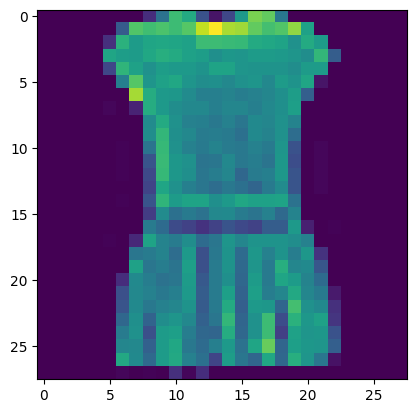

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 3

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [10]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [12]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                     tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

In [14]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9459 - loss: 0.1466
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9474 - loss: 0.1442
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9469 - loss: 0.1449
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9467 - loss: 0.1441
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9481 - loss: 0.1418
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9479 - loss: 0.1410
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9495 - loss: 0.1387
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9499 - loss: 0.1383
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9487 - loss: 0.1384
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9500 - loss: 0.1365
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9511 - loss: 0.1349
Epoch 12/100
1875/1

In [15]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.5925


[0.5925108194351196, 0.8816999793052673]

In [16]:
classifications = model.predict(test_images)

print(classifications[34])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[3.6424790e-28 1.5628590e-32 2.3994090e-35 4.1621825e-32 3.5589227e-24 3.3258293e-19 1.0721947e-34 2.7785742e-38 9.9999994e-01 0.0000000e+00]


In [17]:
print(test_labels[3])

1


Saving mens coat.jpg to mens coat.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


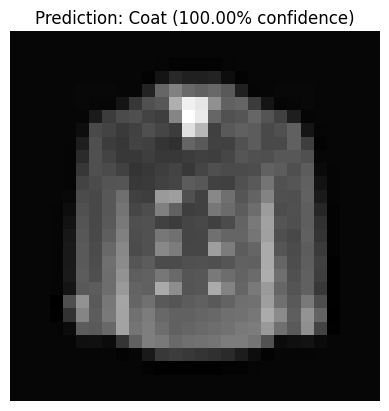

Uploaded file: mens coat.jpg
Predicted class number: 4
Predicted class name: Coat
Confidence: 100.00%
All class probabilities:
T-shirt/top: 0.00%
Trouser: 0.00%
Pullover: 0.00%
Dress: 0.00%
Coat: 100.00%
Sandal: 0.00%
Shirt: 0.00%
Sneaker: 0.00%
Bag: 0.00%
Ankle boot: 0.00%


In [21]:
# Upload your own image and predict the Fashion MNIST class
# Run this cell AFTER training the model.

from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Upload an image file: png, jpg, jpeg, etc.
uploaded = files.upload()

for file_name in uploaded.keys():
    # 1. Open uploaded image
    img = Image.open(file_name).convert("L")   # convert to grayscale

    # 2. Resize image to 28 x 28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))

    # 3. Fashion MNIST usually has a dark background and light object.
    # If your uploaded image has a white background, invert it.
    img = ImageOps.invert(img)

    # 4. Convert image into numpy array and normalize values from 0 to 1
    img_array = np.array(img) / 255.0

    # 5. Add batch dimension: model expects shape (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # 6. Predict
    prediction = model.predict(img_input)
    predicted_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    # 7. Show result
    plt.imshow(img_array, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2f}% confidence)")
    plt.show()

    print("Uploaded file:", file_name)
    print("Predicted class number:", predicted_index)
    print("Predicted class name:", class_names[predicted_index])
    print(f"Confidence: {confidence:.2f}%")
    print("All class probabilities:")
    for name, prob in zip(class_names, prediction[0]):
        print(f"{name}: {prob*100:.2f}%")



In [22]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def predict_fashion_image(uploaded_image):
    """
    This function takes an uploaded image,
    preprocesses it like Fashion MNIST,
    and predicts its class using the trained model.
    """

    # Convert uploaded image to grayscale
    img = uploaded_image.convert("L")

    # Resize image to 28x28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))

    # Invert image colors to match Fashion MNIST style
    img = ImageOps.invert(img)

    # Convert image to numpy array
    img_array = np.array(img)

    # Normalize pixel values from 0-255 to 0-1
    img_array = img_array / 255.0

    # Add batch dimension: (28, 28) becomes (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # Predict using trained model
    prediction = model.predict(img_input)

    # Get predicted class index
    predicted_index = np.argmax(prediction[0])

    # Get confidence percentage
    confidence = np.max(prediction[0]) * 100

    # Create result text
    result = f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}%"

    # Return all class probabilities also
    probabilities = {
        class_names[i]: float(prediction[0][i])
        for i in range(len(class_names))
    }

    return result, probabilities


# Create Gradio interface
demo = gr.Interface(
    fn=predict_fashion_image,
    inputs=gr.Image(type="pil", label="Upload Fashion Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(num_top_classes=10, label="Class Probabilities")
    ],
    title="Fashion MNIST Image Classifier",
    description="Upload an image of clothing, shoes, or bag. The model will predict the Fashion MNIST class."
)

# Launch app
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://90ee1e07a122729a1c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
